Week 1: Data Exploration and first MRI Visualizations

Imports

In [ ]:
import nibabel as nib # MRI file reader tool
import numpy as np # math/numbers tool 
import matplotlib.pyplot as plt # drawing/visualization tool
import os # the file navigation tool

Loading First Patient

In [7]:
# Point to your first patient folder
patient_path = r"C:\Users\sanja\OneDrive\Desktop\bioinformaticsprojects\brain-tumor-segmentation\data\BraTS2020_TrainingData\MICCAI_BraTS2020_TrainingData\BraTS20_Training_001"

# Load all 2 modalities + the tumor mask
flair = nib.load(os.path.join(patient_path,"BraTS20_Training_001_flair.nii")).get_fdata()
t1 = nib.load(os.path.join(patient_path, "BraTS20_Training_001_t1.nii")).get_fdata()
t1ce = nib.load(os.path.join(patient_path, "BraTS20_Training_001_t1ce.nii")).get_fdata()
t2 = nib.load(os.path.join(patient_path, "BraTS20_Training_001_t2.nii")).get_fdata()
mask = nib.load(os.path.join(patient_path, "BraTS20_Training_001_seg.nii")).get_fdata()

# Print the shape of the flair volume
print(f"Volume shape: {flair.shape}")

# Print the unique label values in the mask
print(f"Unique label values in the mask: {np.unique(mask)}")


Volume shape: (240, 240, 155)
Unique label values in the mask: [0. 1. 2. 4.]


Visualizing all 4 Modalities

T1 = normal brain anatomy - good for seeing overall brain structure

T1ce = tumor core - a contrast dye is injected and it lights up the most active tumor regions 

T2 = swelling and fluid - shows edema (the area around the tumor that's inflamed)

FLAIR = abnormal tissue - similar to T2 but suppresses normal fluid so the tumor edges are clearer

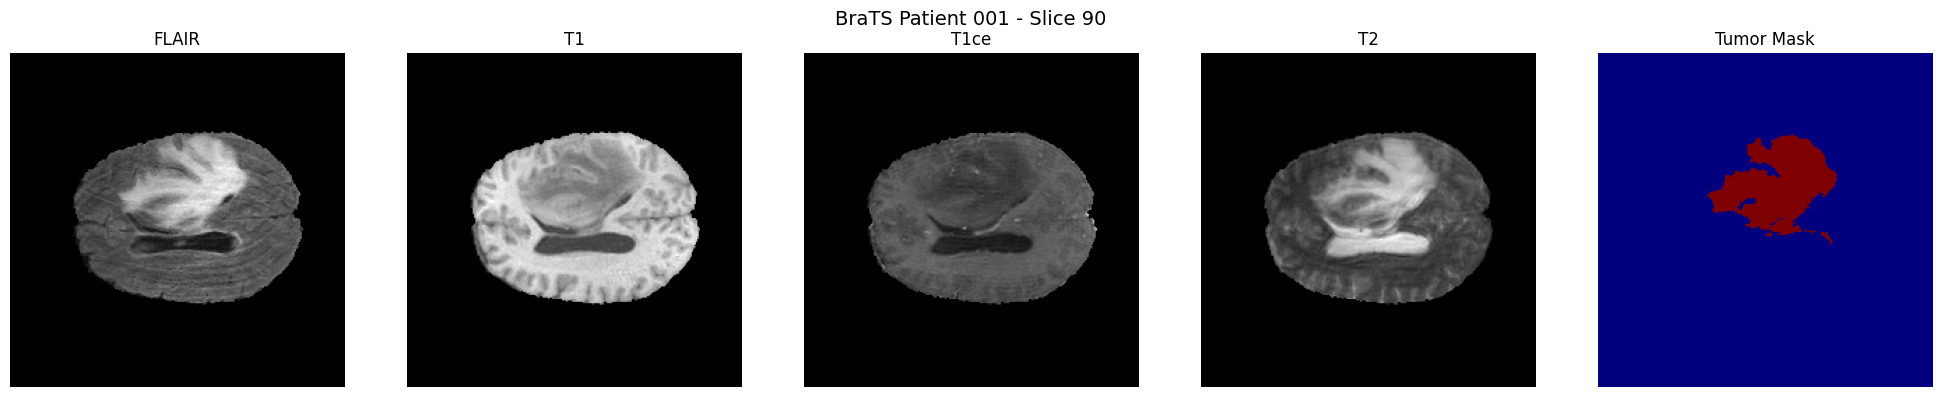

In [8]:
# Choose which slice ot look at (90 is a good middle slice)
slice_idx = 90

fig, axes = plt.subplots(1, 5, figsize= (20,4))

# Display FLAIR
axes[0].imshow(flair[:, :, slice_idx], cmap="gray")
axes[0].set_title("FLAIR")

# Display T1
axes[1].imshow(t1[:, :, slice_idx], cmap = "gray")
axes[1].set_title("T1")

# Display T1ce
axes[2].imshow(t1ce[:, :, slice_idx], cmap = "gray")
axes[2].set_title("T1ce")

# Display T2
axes[3].imshow(t2[:, :, slice_idx], cmap = "gray")
axes[3].set_title("T2")

# Display the tumor mask (use cmap ="jet" instead of "gray" so it shows in color)
axes[4].imshow(mask[:, :, slice_idx], cmap = "jet")
axes[4].set_title("Tumor Mask")

#Turn off the axes lines for all 5 images
for ax in axes:
    ax.axis("off")

plt.suptitle("BraTS Patient 001 - Slice 90", fontsize=14)
plt.tight_layout()
plt.show()

Overlay the mask on the FLAIR scan

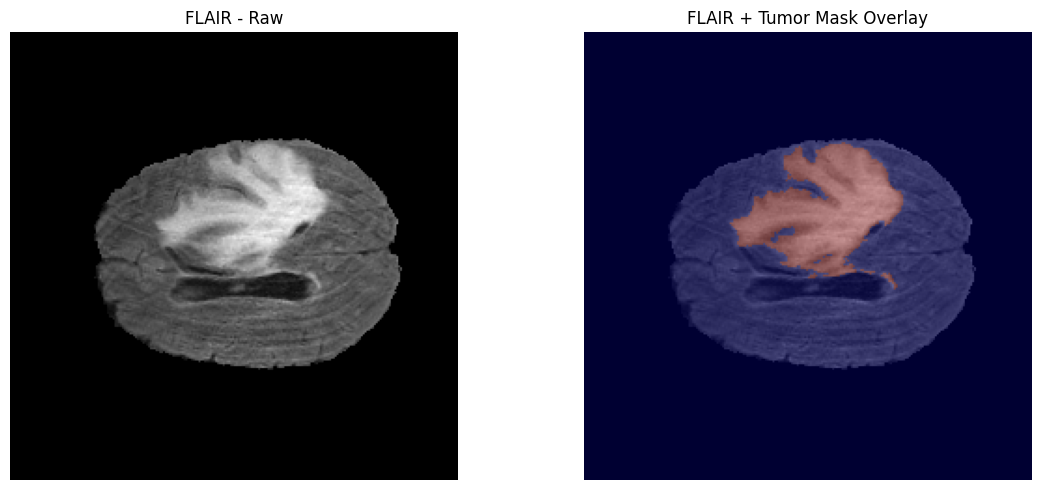

In [15]:
slice_flair = flair[:, :, slice_idx]
slice_mask = mask[:, :, slice_idx]

# Normalize FLAIR to 0-1 for display
slice_flair_norm = (slice_flair - slice_flair.min()) / (slice_flair.max() - slice_flair.min())

fig, axes = plt.subplots(1, 2, figsize = (12,5))

# Show the raw FLAIR scan on the left
axes[0].imshow(slice_flair_norm, cmap = "gray")
axes[0].set_title("FLAIR - Raw")
axes[0].axis("off")

#Show the FLAIR scan on the right with the tumor mask overlaid on top
axes[1].imshow(slice_flair_norm, cmap="gray")
axes[1].imshow(slice_mask, cmap="jet", alpha=0.4)
axes[1].set_title("FLAIR + Tumor Mask Overlay")
axes[1].axis("off")

plt.tight_layout()
plt.show()